<a href="https://colab.research.google.com/github/HelloJacob11/-Federal-Regulatory-Comment-Analysis-System/blob/main/Double_Moving_Average_Crossover_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance          # in Colab
import yfinance as yf
import numpy as np
import pandas as pd

In [ ]:
data = yf.download("SPY", start="2005-01-01", auto_adjust=False)
if isinstance(data.columns,pd.MultiIndex):
  data.columns = data.columns.droplevel(1)
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price       Adj Close       Close        High         Low        Open  \
Date                                                                    
2005-01-03  81.174576  120.300003  121.760002  119.900002  121.559998   
2005-01-04  80.182693  118.830002  120.540001  118.440002  120.459999   
2005-01-05  79.629379  118.010002  119.250000  118.000000  118.739998   
2005-01-06  80.034233  118.610001  119.150002  118.260002  118.440002   
2005-01-07  79.919487  118.440002  119.230003  118.129997  118.970001   

Price         Volume  
Date                  
2005-01-03  55748000  
2005-01-04  69167600  
2005-01-05  65667300  
2005-01-06  47814700  
2005-01-07  55847700  


In [ ]:
data['sma_fast'] = data['Adj Close'].rolling(window=20).mean()   # 20-day SMA
data['sma_slow'] = data['Adj Close'].rolling(window=50).mean()   # 50-day SMA

In [ ]:
#data['ema_fast'] = data['Adj Close'].ewm(span=20, adjust=False).mean().  #EMA (saved for later)
#data['ema_slow'] = data['Adj Close'].ewm(span=50, adjust=False).mean()

In [ ]:
data['signal'] = (data['sma_fast'] > data['sma_slow']).astype(int)   # 1 = long, 0 = flat

# Case1

In [ ]:
data['position'] = data['signal'].shift(1)
data['ret'] = data['Adj Close'].pct_change() # 등락
data['strat_ret'] = data['position'] * data['ret'] # 전략 수익률

In [ ]:
capital = 10000
data['Strategy_Value'] = capital * (1 + data['strat_ret']).cumprod()
data['Market_Value'] = capital * (1 + data['ret']).cumprod()

In [ ]:
data.head(5)

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,ret,strat_ret
Date,,,,,,,,,,,,
2005-01-03,81.174576,120.300003,121.760002,119.900002,121.559998,55748000,NaN,NaN,0,NaN,NaN,NaN
2005-01-04,80.182693,118.830002,120.540001,118.440002,120.459999,69167600,NaN,NaN,0,0.0,-0.012219,-0.0
2005-01-05,79.629379,118.010002,119.250000,118.000000,118.739998,65667300,NaN,NaN,0,0.0,-0.006901,-0.0
2005-01-06,80.034233,118.610001,119.150002,118.260002,118.440002,47814700,NaN,NaN,0,0.0,0.005084,0.0
2005-01-07,79.919487,118.440002,119.230003,118.129997,118.970001,55847700,NaN,NaN,0,0.0,-0.001434,-0.0


In [ ]:
data.tail(5)

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,ret,strat_ret,Strategy_Value,Market_Value
Date,,,,,,,,,,,,,,
2026-09-08,765.960022,765.960022,769.700012,765.140015,769.070007,44746100,768.699493,757.596602,1,1.0,-0.005492,-0.005492,34121.130803,94359.596508
2026-09-09,762.400024,762.400024,764.469971,760.940002,764.080017,32812400,768.291495,758.024602,1,1.0,-0.004648,-0.004648,33962.544012,93921.035847
2026-09-10,757.830017,757.830017,760.109985,756.640015,758.030029,42740400,767.558496,758.245802,1,1.0,-0.005994,-0.005994,33758.964434,93358.050790
2026-09-11,764.289978,764.289978,766.380005,763.599976,764.719971,45512700,766.878995,758.616401,1,1.0,0.008524,0.008524,34046.735552,94153.861655
2026-09-14,760.880005,760.880005,763.520020,757.929993,759.000000,43944500,766.105994,758.938401,1,1.0,-0.004462,-0.004462,33894.831881,93733.782694


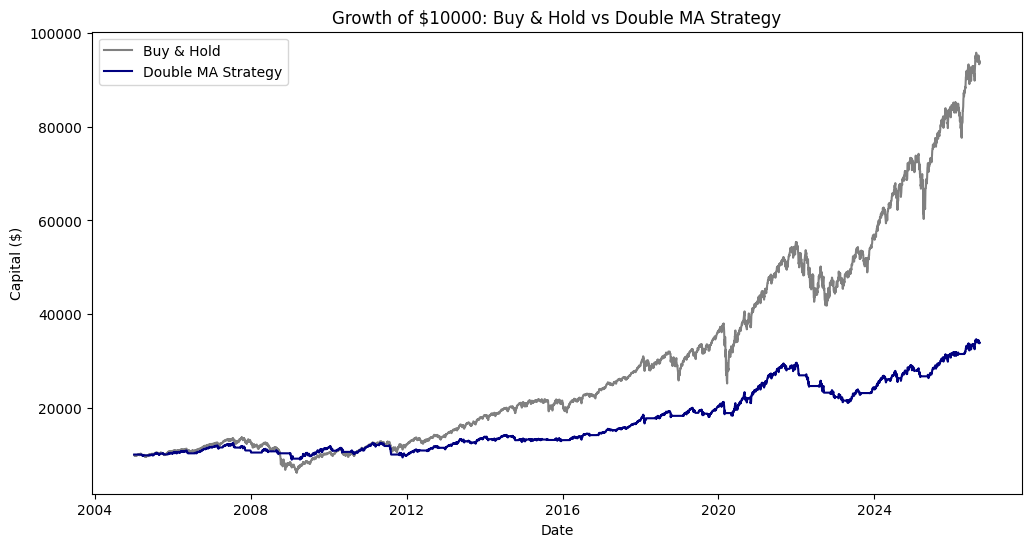

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 6))
plt.plot(data.index, data['Market_Value'], label = "Buy & Hold", color = "grey")
plt.plot(data.index, data['Strategy_Value'], label = "Double MA Strategy", color = "navy")
plt.xlabel("Date")
plt.ylabel("Capital ($)")
plt.legend()
plt.title(f"Growth of ${capital}: Buy & Hold vs Double MA Strategy")
plt.show()

In [ ]:
cost_per_trade = 0.0005                                   # 5 bps
data['trade'] = data['position'].diff().abs()             # 1 when you enter or exit
data['strat_ret_net'] = data['strat_ret'] - data['trade'] * cost_per_trade

Equity Curve
Strategy: “If I followed my trading strategy, how would my money have grown over time?”

Benchmark: “What if I had just bought the asset at the beginning and never traded it?”

In [ ]:
data['equity'] = (1 + data['strat_ret_net']).cumprod()
data['equity_bh'] = (1 + data['ret']).cumprod()           # buy-and-hold benchmark

Sharpe ratio — return per unit of risk (volatility)
* Divide average return by its standard deviation (how bumpy the ride was)

In [ ]:
sharpe = data['strat_ret_net'].mean() / data['strat_ret_net'].std() * np.sqrt(252)

Max Drawdown: largest percentage drop an investment experiences from a peak value to a trough value before setting a new high.

In [ ]:
running_max = data['equity'].cummax()
drawdown = data['equity'] / running_max - 1
max_dd = drawdown.min()                                    # e.g. -0.35 = down 35%

CAGR (compound annual growth rate)

In [ ]:
years = len(data) / 252
cagr = data['equity'].iloc[-1] ** (1/years) - 1

Volatility

In [ ]:
data['volatility_20d'] = data['ret'].rolling(20).std()

Moving Average Ratio

In [ ]:
data['sma_ratio'] = data['sma_fast'] / data['sma_slow']

RSI (Relative Strength Index)

In [ ]:
delta = data['Adj Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

data['rsi'] = 100 - (100 / (1 + rs))


Volume

In [ ]:
data['volume_ratio'] = (
    data['Volume'] /
    data['Volume'].rolling(20).mean()
)

In [ ]:
data['target']= data['ret'].shift(-1)

In [ ]:
data.head()

Price,Adj Close,Close,High,Low,Open,Volume,sma_fast,sma_slow,signal,position,...,strat_ret,trade,strat_ret_net,equity,equity_bh,volatility_20d,sma_ratio,rsi,volume_ratio,target
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,81.174606,120.300003,121.760002,119.900002,121.559998,55748000,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012295
2005-01-04,80.182701,118.830002,120.540001,118.440002,120.459999,69167600,NaN,NaN,0,0.0,...,-0.0,NaN,NaN,NaN,0.987705,NaN,NaN,NaN,NaN,-0.006924
2005-01-05,79.629395,118.010002,119.250000,118.000000,118.739998,65667300,NaN,NaN,0,0.0,...,-0.0,0.0,-0.0,1.0,0.980866,NaN,NaN,NaN,NaN,0.005071
2005-01-06,80.034248,118.610001,119.150002,118.260002,118.440002,47814700,NaN,NaN,0,0.0,...,0.0,0.0,0.0,1.0,0.985840,NaN,NaN,NaN,NaN,-0.001435
2005-01-07,79.919502,118.440002,119.230003,118.129997,118.970001,55847700,NaN,NaN,0,0.0,...,-0.0,0.0,-0.0,1.0,0.984426,NaN,NaN,NaN,NaN,0.004717


Out of Sample Testing

In [ ]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# X: 20-day SMA = data['sma_fast']
# X: 50-day SMA = data['sma_slow']
# X: 20-day Volatility = data['volatility_20d']
# X: Relative Strength Index (RSI) = data['rsi']

# Y: Target = data['target']

Step 10: Plot equity vs equity_bh

```
data['ret']
data['sma_fast']
data['sma_slow']
data['ema_fast']
data['ema_slow']

20-day SMA       ─┐
50-day SMA        │
20-day EMA        │
50-day EMA        ├──→ ML model (Regression) ──→ UP / DOWN
5-day return      │
20-day volatility │
RSI               │
volume           ─┘

Date	SMA fast	SMA slow	EMA fast	EMA slow	Return
Day 1	100	98	101	99	0.01
Day 2	101	99	102	100	-0.02
Day 3	99	100	100	101	0.03


"Based on these clues, will SPY be up over the next 5 days?"
Target Value
If yes (value >0): 1
If no (value < 0): 0

Compare double moving average vs. benchmark vs ml`
````